## POMDPs for modeling treatment procedures through patient symptoms and gender


Previous research [https://pmc.ncbi.nlm.nih.gov/articles/PMC10688448/] has identified a gender-pain exaggeration bias where people tend to believe women exaggerate while men downplay the pain they experience. Perceivers judge women as more likely to claim greater pain than they actually experience, while men are expected to report less pain than they feel. This bias appears to be driven by stereotypes characterizing women as more emotionally dramatic than men.

To better understand how this bias affects medical decision-making, we are implementing a Partially Observable Markov Decision Process (POMDP) model. POMDPs are mathematical frameworks designed for sequential decision-making under uncertainty, where:

1. The true state (in this case, a patient's actual pain level) is not directly observable
2. The decision-maker must rely on observations (in this simplified example, this is patient self-reporting their symptoms) that provide incomplete information
3. The decision-maker maintains a "belief state" (probability distribution over possible disease severity)
3. Actions are chosen to maximize expected rewards over time
Our POMDP model will specifically:

1. Incorporate the gender-pain exaggeration bias by adjusting how practitioners interpret pain reports based on patient gender
2. Compare optimal treatment policies derived by biased versus unbiased practitioners
3. Quantify disparities in potential cost to patients per gender due to practitioner bias

This computational approach allows us model how cognitive biases distort clinical judgment and potentially contribute to the documented undertreatment of severity of womens symptoms in healthcare settings. By simulating decision processes with and without bias, we can identify specific intervention points to improve equitable and more effective treatment procedures. 



We will be using this paper https://link.springer.com/article/10.1007/s00415-022-11176-x for transition probabilities.

### Unbiased model

Here we explore outcomes if all patients were treated the same way (no bias from healthcare practitioners). 

In [140]:
from memo import memo
import jax
import jax.numpy as np
# from icecream import ic
from functools import cache
from enum import IntEnum
import jax.numpy as jnp

# states represent the true severity of patient's condition
class S(IntEnum):
    Severe = 0
    Mild = 1

# actions represent different treatment options
class A(IntEnum):
    IntensiveTreatment = 0
    ModerateTreatment = 1
    Observation = 2

# observations are symptoms and pain report
class O(IntEnum):
    HighSymptoms = 0
    ModerateSymptoms = 1
    LowSymptoms = 2

# belief space, discretized into 50 possible belief states of two dimesions
# define the range for each dimension
x = jnp.linspace(0, 1, 50)
y = jnp.linspace(0, 1, 50)
B_2D = jnp.stack((x, y), axis=0)
# print(B_2D.shape) 
# print(B_2D)

B=jnp.linspace(0, 1, 50)


In [86]:
@jax.jit
def get_belief(b,s):
    return np.array([b,1-b])[s]

@jax.jit
def get_belief_3D(b,s):
    return np.array([b[0],b[1], 1-b[0]-b[1]])[s]


@jax.jit
def Tr(s,a,s_):
    # transition probabilities: P(s_|s,a)
    # how the patient's condition changes based on treatment
    transitions = np.array([
        # P(s_|Severe, a) <-- 2 states, 3 actions, 2 states
        [
            [0.2, 0.8],  # IntensiveTreatment: good chance of improvement
            [0.4, 0.6],  # ModerateTreatment: likely stays severe
            [0.9, 0.1]   # Observation: likely worsens
        ],
        # P(s_|Mild, a)
        [
            [0.6, 0.4],  # IntensiveTreatment: likely worsens (side effects)
            [0.3, 0.7],  # ModerateTreatment: gets better (less side effects)
            [0.4, 0.6]   # Observation: mostly stays mild, might worsen
        ]
    ])
    return transitions[s,a,s_]

@jax.jit
def Obs(s,a,o):
    observations = np.array([
    # observation probabilities: P(o|s,a) <-- 2 states, 3 actions, 3 observations 
    # what symptoms we observe given the true state and treatment
        [
            [0.1, 0.4, 0.5],  # IntensiveTreatment: high symptoms
            [0.3, 0.4, 0.3],  # ModerateTreatment: moderate symptoms
            [0.5, 0.4, 0.1]   # Observation: low symptoms
        ],
        # P(o|Mild, a)
        [
            [0.1, 0.4, 0.5],  # IntensiveTreatment: high symptoms
            [0.2, 0.6, 0.2],  # ModerateTreatment: moderate symptoms
            [0.3, 0.6, 0.1]   # Observation: low symptoms
        ]
    ])
    return observations[s,a,o]




In [ ]:
@jax.jit
def R_doctor(s, a):
    # base health impact (objective medical outcome)
    health_impact = np.array([-30, -3])[s]
    # very costly to have the patient be very sick (severe)
    # less costly to have the patient be mildly sick (mild)
    
    # financial incentives 
    financial_incentive = np.array([5, 3, 11])[a]
    # it is beneficial to the doctor to keep the patient in the hospital (intensive treatment)
    # it is less financially beneficial to prescribe medication (moderate treatment)
    # it is moderately financially beneficial to observe the patient, which translates to booking another appointment (observation)
    
    # total reward
    return health_impact + financial_incentive

@jax.jit
def R_patient(s, a):
    health_impact = np.array([-37, -2])[s]
    
    financial_incentive = np.array([-20, -5, -7])[a]
    # it is very costly for the patient to stay in the hospital (intensive treatment)
    # it is least costly to take medication (moderate treatment)
    # it is less costly for patient to book another appointment (observation)
    return health_impact + financial_incentive

In [88]:
@memo(cache=True)
def Q[b: B, a: A](t):
    doctor: knows(b, a)  # the doctor knows the current belief state and action.
    doctor: thinks[
        env: knows(b, a),  # the environment also knows the current belief state and action.
        env: given(s in S, wpp=get_belief(b, s)),  # the environment samples the true state `s` based on the belief `b`.
        env: given(s_ in S, wpp=Tr(s, a, s_)),  # the environment transitions to the next state `s_` based on the current state `s` and action `a`.
        env: given(o in O, wpp=Obs(o, s_, a))  # the environment generates an observation `o` based on the next state `s_` and action `a`.
    ]
    doctor: snapshots_self_as(future_doctor)  # the doctor imagines a future version of themselves.

    return doctor[
        E[R_doctor(env.s, a)] +  # the expected immediate reward for the doctor.
        (0.0 if t <= 0 else 0.9 * imagine[  # if time `t` is greater than 0, the doctor imagines future rewards.
            future_doctor: observes [env.o] is env.o,  # the future doctor observes the observation `o`.
            future_doctor: chooses(b_ in B, wpp=exp(-130.0 * abs(E[env.s_ == 0] - b_))),  # the future doctor updates their belief state `b_` to minimize the distance to the true state.
            future_doctor: chooses(a_ in A, to_maximize=Q[b_, a_](t - 1)),  # the future doctor chooses the action `a_` that maximizes the Q-value for the updated belief state `b_` and time `t-1`.
            E[future_doctor[ Q[b_, a_](t - 1) ]]  # the expected Q-value for the future doctor.
        ])
    ]

# measure the time it takes to compute the Q-value for a belief state `b` and action `a` at time `t=100`.
%timeit -r 10 -n 10 Q.cache_clear(); Q(100).block_until_ready()


73.7 ms ± 7.67 ms per loop (mean ± std. dev. of 10 runs, 10 loops each)


In [89]:

@memo(cache=True)
def Q_doctor[b: B, a: A](t):
    doctor: knows(b, a)
    doctor: thinks[
        env: knows(b, a),
        env: given(s in S, wpp=get_belief(b, s)),
        env: given(s_ in S, wpp=Tr(s, a, s_)),
        env: given(o in O, wpp=Obs(o, s_, a))
    ]
    doctor: snapshots_self_as(future_doctor)

    return doctor[
        E[R_doctor(env.s, a)] +
        (0.0 if t <= 0 else 0.9 * imagine[
            future_doctor: observes [env.o] is env.o,
            future_doctor: chooses(b_ in B, wpp=exp(-130.0 * abs(E[env.s_ == 0] - b_))),
            future_doctor: chooses(a_ in A, to_maximize=Q_doctor[b_, a_](t - 1)),
            E[future_doctor[ Q_doctor[b_, a_](t - 1) ]]
        ])
    ]

@memo(cache=True)
def Q_patient[b: B, a: A](t):
    doctor: knows(b, a)
    doctor: thinks[
        env: knows(b, a),
        env: given(s in S, wpp=get_belief(b, s)),
        env: given(s_ in S, wpp=Tr(s, a, s_)),
        env: given(o in O, wpp=Obs(o, s_, a))
    ]
    doctor: snapshots_self_as(future_doctor)

    return doctor[
        E[R_patient(env.s, a)] +
        (0.0 if t <= 0 else 0.9 * imagine[
            future_doctor: observes [env.o] is env.o,
            future_doctor: chooses(b_ in B, wpp=exp(-130.0 * abs(E[env.s_ == 0] - b_))),
            # important: Use the doctor's optimal action here, based on doctor's reward
            future_doctor: chooses(a_ in A, to_maximize=Q_doctor[b_, a_](t - 1)),
            # but calculate using patient's reward function
            E[future_doctor[ Q_patient[b_, a_](t - 1) ]]
        ])
    ]
    

@memo(cache=True) # this time the doctor's reward function is the same as the patient's
def Q_singular[b: B, a: A](t):
    doctor: knows(b, a)
    doctor: thinks[
        env: knows(b, a),
        env: given(s in S, wpp=get_belief(b, s)),
        env: given(s_ in S, wpp=Tr(s, a, s_)),
        env: given(o in O, wpp=Obs(o, s_, a))
    ]
    doctor: snapshots_self_as(future_doctor)

    return doctor[
        E[R_patient(env.s, a)] +
        (0.0 if t <= 0 else 0.9 * imagine[
            future_doctor: observes [env.o] is env.o,
            future_doctor: chooses(b_ in B, wpp=exp(-130.0 * abs(E[env.s_ == 0] - b_))),
            future_doctor: chooses(a_ in A, to_maximize=Q_singular[b_, a_](t - 1)),
            # calculate using patient's reward function
            E[future_doctor[ Q_singular[b_, a_](t - 1) ]]
        ])
    ]
    


# measure the time it takes to compute the Q-value for a belief state `b` and action `a` at time `t=100`.
%timeit -r 10 -n 10 Q_doctor.cache_clear(); Q_doctor(100).block_until_ready()
%timeit -r 10 -n 10 Q_patient.cache_clear(); Q_patient(100).block_until_ready()

79.6 ms ± 17.8 ms per loop (mean ± std. dev. of 10 runs, 10 loops each)
74 ms ± 17.1 ms per loop (mean ± std. dev. of 10 runs, 10 loops each)


In [90]:
# Run the solvers
q_doctor = Q_doctor(10) # optimal policy for doctor
q_patient_under_doctor_policy = Q_patient(10) # patient's reward under doctor's policy
q_patient = Q_singular(10) # optimal policy for patient

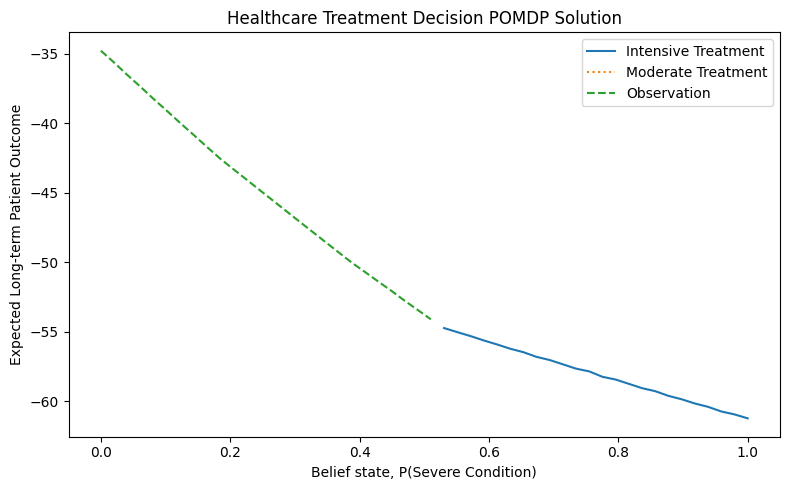

In [91]:
# print(q)  
v = np.max(q_doctor, axis=1, keepdims=True)  # optimal action for each belief state
p = (q_doctor == v) * 1.0  # optimal action indicator

# this line creates a binary array p that indicates the optimal actions for each state.
# the expression (q == v) compares the Q-values in q with the maximum Q-values in v,
# resulting in a boolean array where True indicates that the Q-value is equal to the maximum Q-value.
# multiplying by 1.0 converts the boolean array to a float array, where 1.0 indicates the optimal actions and 0.0 indicates non-optimal actions.
v = v.squeeze(-1)

# make the figure
from matplotlib import pyplot as plt
plt.figure(figsize=(8, 5))
plt.plot(B[p[:, 0] == 1], v[p[:, 0] == 1], label='Intensive Treatment')
plt.plot(B[p[:, 1] == 1], v[p[:, 1] == 1], ':', label='Moderate Treatment')
plt.plot(B[p[:, 2] == 1], v[p[:, 2] == 1], '--', label='Observation')
plt.legend()
plt.xlabel('Belief state, P(Severe Condition)')
plt.ylabel('Expected Long-term Patient Outcome')
plt.title('Healthcare Treatment Decision POMDP Solution')
plt.tight_layout()
plt.savefig('healthcare_pomdp.pdf')

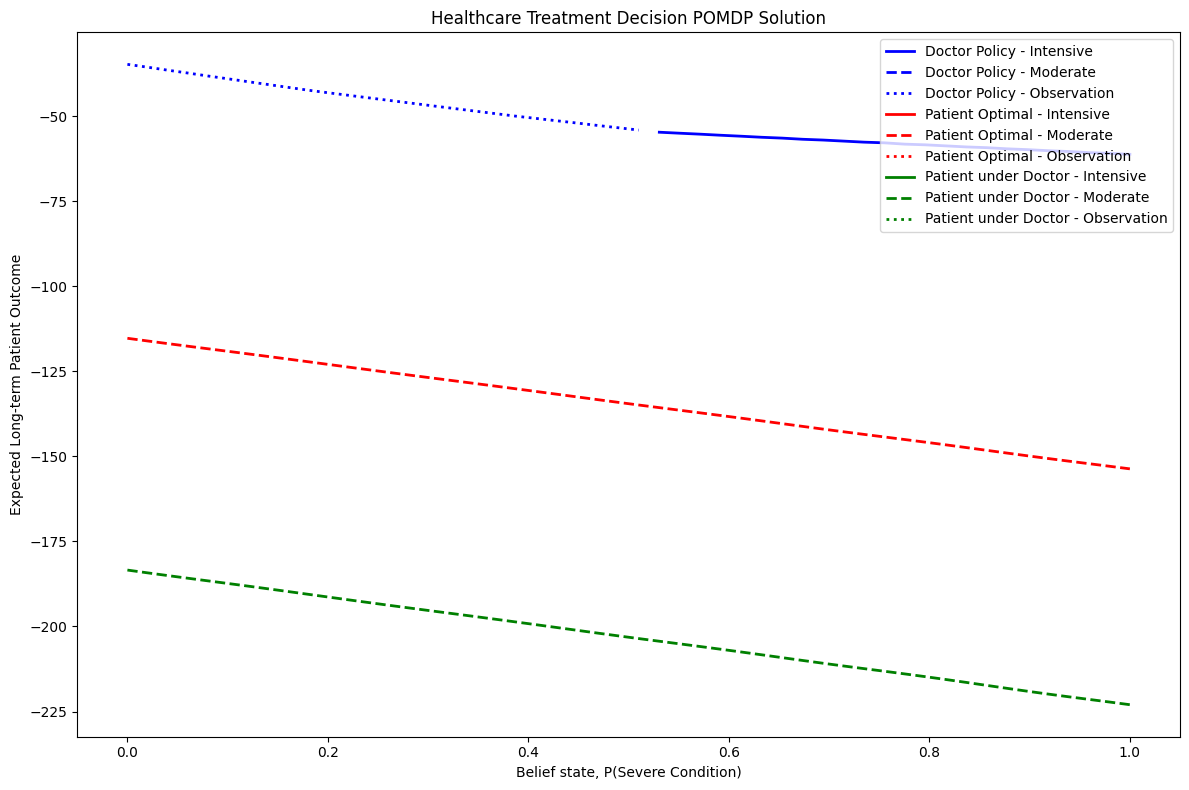

In [92]:
# calculate optimal values and actions for each policy
# doctor's policy
v_doctor = np.max(q_doctor, axis=1, keepdims=True)
p_doctor = (q_doctor == v_doctor) * 1.0
v_doctor = v_doctor.squeeze(-1)

# patient's policy
v_patient = np.max(q_patient, axis=1, keepdims=True)
p_patient = (q_patient == v_patient) * 1.0
v_patient = v_patient.squeeze(-1)

# patient under doctor's policy
v_patient_under_doctor = np.max(q_patient_under_doctor_policy, axis=1, keepdims=True)
p_patient_under_doctor = (q_patient_under_doctor_policy == v_patient_under_doctor) * 1.0
v_patient_under_doctor = v_patient_under_doctor.squeeze(-1)

# create the figure
from matplotlib import pyplot as plt
plt.figure(figsize=(12, 8))

# plot doctor's optimal policy (using solid lines)
plt.plot(B[p_doctor[:, 0] == 1], v_doctor[p_doctor[:, 0] == 1], 'b-', linewidth=2, label='Doctor Policy - Intensive')
plt.plot(B[p_doctor[:, 1] == 1], v_doctor[p_doctor[:, 1] == 1], 'b--', linewidth=2, label='Doctor Policy - Moderate')
plt.plot(B[p_doctor[:, 2] == 1], v_doctor[p_doctor[:, 2] == 1], 'b:', linewidth=2, label='Doctor Policy - Observation')

# Plot Patient's Optimal Policy (using red lines)
plt.plot(B[p_patient[:, 0] == 1], v_patient[p_patient[:, 0] == 1], 'r-', linewidth=2, label='Patient Optimal - Intensive')
plt.plot(B[p_patient[:, 1] == 1], v_patient[p_patient[:, 1] == 1], 'r--', linewidth=2, label='Patient Optimal - Moderate')
plt.plot(B[p_patient[:, 2] == 1], v_patient[p_patient[:, 2] == 1], 'r:', linewidth=2, label='Patient Optimal - Observation')

# plot patient under doctor's policy (using green lines)
plt.plot(B[p_patient_under_doctor[:, 0] == 1], v_patient_under_doctor[p_patient_under_doctor[:, 0] == 1], 'g-', linewidth=2, label='Patient under Doctor - Intensive')
plt.plot(B[p_patient_under_doctor[:, 1] == 1], v_patient_under_doctor[p_patient_under_doctor[:, 1] == 1], 'g--', linewidth=2, label='Patient under Doctor - Moderate')
plt.plot(B[p_patient_under_doctor[:, 2] == 1], v_patient_under_doctor[p_patient_under_doctor[:, 2] == 1], 'g:', linewidth=2, label='Patient under Doctor - Observation')

plt.legend()
plt.xlabel('Belief state, P(Severe Condition)')
plt.ylabel('Expected Long-term Patient Outcome')
plt.title('Healthcare Treatment Decision POMDP Solution')
plt.tight_layout()


Average cost to patient: 68.6577
Maximum cost to patient: 69.3130 at belief = 1.00
Minimum cost to patient: 68.1175 at belief = 0.00


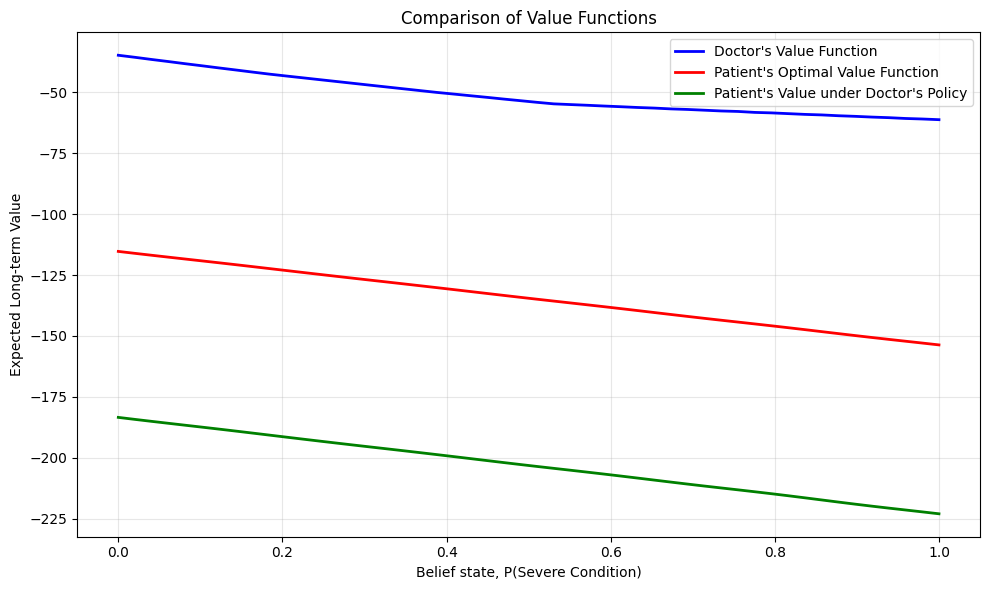

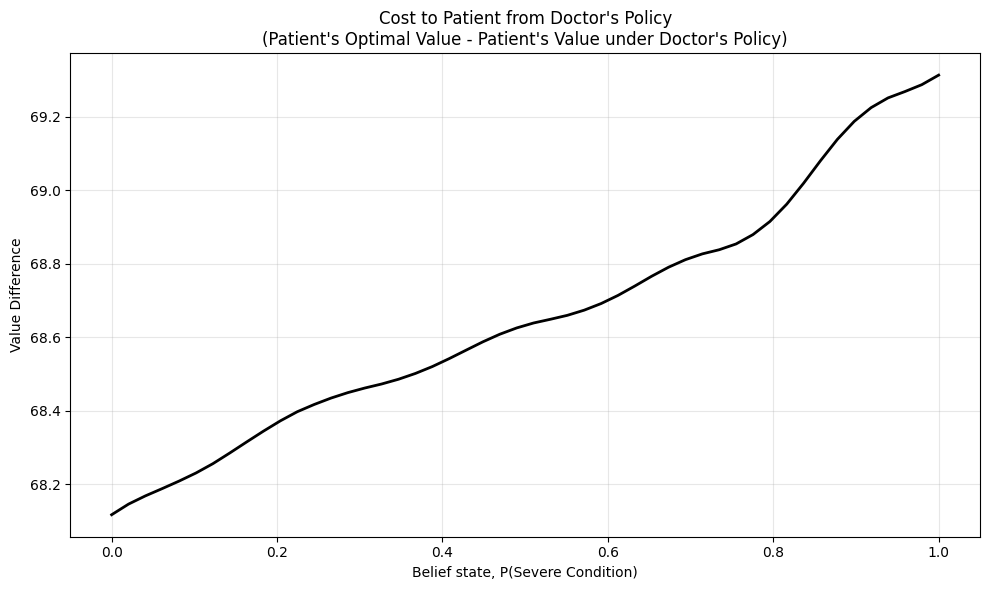

In [96]:
# a second plot that shows just the value functions without splitting by action
plt.figure(figsize=(10, 6))
plt.plot(B, v_doctor, 'b-', linewidth=2, label='Doctor\'s Value Function')
plt.plot(B, v_patient, 'r-', linewidth=2, label='Patient\'s Optimal Value Function')
plt.plot(B, v_patient_under_doctor, 'g-', linewidth=2, label='Patient\'s Value under Doctor\'s Policy')
plt.xlabel('Belief state, P(Severe Condition)')
plt.ylabel('Expected Long-term Value')
plt.title('Comparison of Value Functions')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('healthcare_value_comparison.pdf')

# calculate and print the "cost to patient" from doctor's policy
cost_to_patient = v_patient - v_patient_under_doctor
plt.figure(figsize=(10, 6))
plt.plot(B, cost_to_patient, 'k-', linewidth=2)
plt.xlabel('Belief state, P(Severe Condition)')
plt.ylabel('Value Difference')
plt.title('Cost to Patient from Doctor\'s Policy\n(Patient\'s Optimal Value - Patient\'s Value under Doctor\'s Policy)')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('cost_to_patient.pdf')

# print some statistics about the cost to patient
print(f"Average cost to patient: {np.mean(cost_to_patient):.4f}")
print(f"Maximum cost to patient: {np.max(cost_to_patient):.4f} at belief = {B[np.argmax(cost_to_patient)]:.2f}")
print(f"Minimum cost to patient: {np.min(cost_to_patient):.4f} at belief = {B[np.argmin(cost_to_patient)]:.2f}")


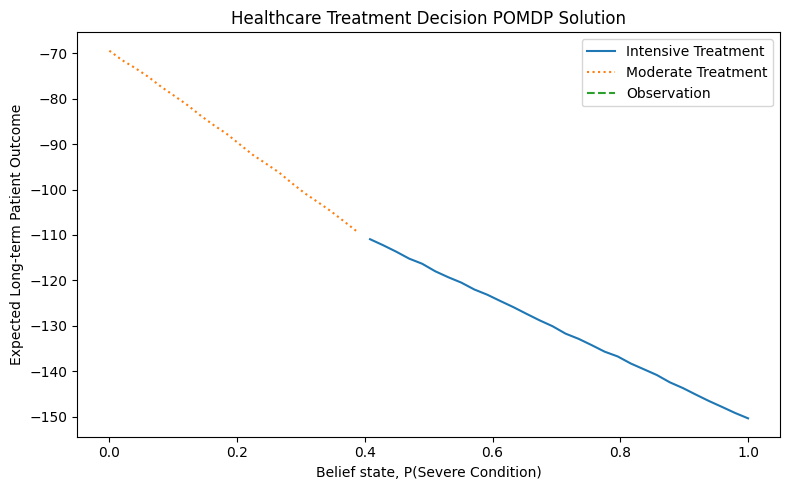

In [26]:
# run the solver
q = Q(10)

# print(q)  
v = np.max(q, axis=1, keepdims=True)  # optimal action for each belief state
p = (q == v) * 1.0  # optimal action indicator

# this line creates a binary array p that indicates the optimal actions for each state.
# the expression (q == v) compares the Q-values in q with the maximum Q-values in v,
# resulting in a boolean array where True indicates that the Q-value is equal to the maximum Q-value.
# multiplying by 1.0 converts the boolean array to a float array, where 1.0 indicates the optimal actions and 0.0 indicates non-optimal actions.
v = v.squeeze(-1)

# make the figure
from matplotlib import pyplot as plt
plt.figure(figsize=(8, 5))
plt.plot(B[p[:, 0] == 1], v[p[:, 0] == 1], label='Intensive Treatment')
plt.plot(B[p[:, 1] == 1], v[p[:, 1] == 1], ':', label='Moderate Treatment')
plt.plot(B[p[:, 2] == 1], v[p[:, 2] == 1], '--', label='Observation')
plt.legend()
plt.xlabel('Belief state, P(Severe Condition)')
plt.ylabel('Expected Long-term Patient Outcome')
plt.title('Healthcare Treatment Decision POMDP Solution')
plt.tight_layout()
plt.savefig('healthcare_pomdp.pdf')

In [ ]:
v = np.max(q, axis=1, keepdims=True)  # optimal action for each belief state

for a in v, R_patient(s, a)

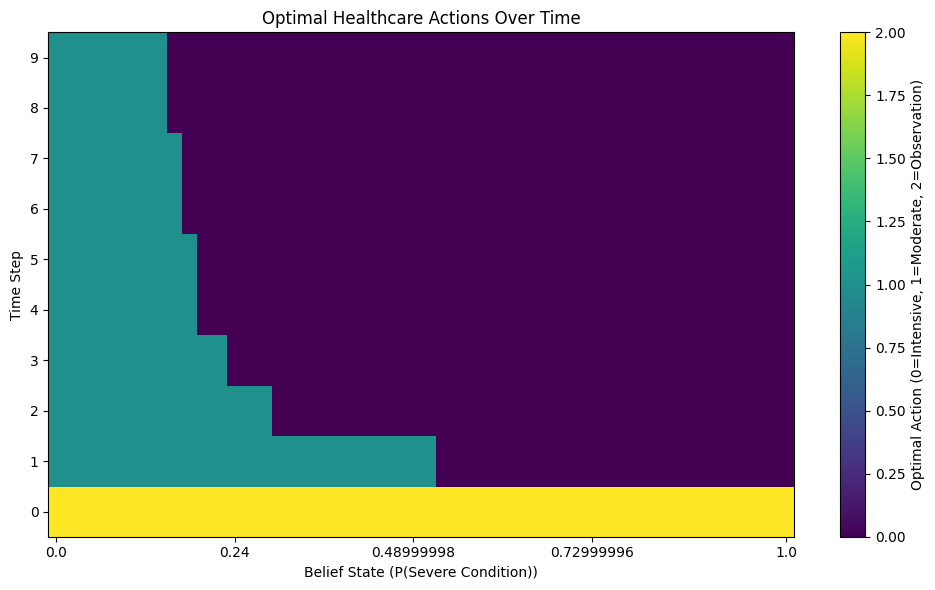

In [32]:
# run the solver
T = 10  # Number of timepoints
q_values = np.stack([Q(t) for t in range(T)])  # Store Q-values for all timepoints

# compute optimal actions
v = np.max(q_values, axis=2, keepdims=True)  # best expected value at each state
p = (q_values == v) * 1.0  # binary array indicating optimal actions (1 if optimal)

# asssign action indices for visualization (0 = Intensive, 1 = Moderate, 2 = Observation)
optimal_actions = np.argmax(p, axis=2)  # Shape: (T, |B|)

# create heatmap
plt.figure(figsize=(10, 6))
plt.imshow(optimal_actions, aspect='auto', cmap='viridis', origin='lower')

# Labels and formatting
plt.colorbar(label="Optimal Action (0=Intensive, 1=Moderate, 2=Observation)")
plt.xlabel("Belief State (P(Severe Condition))")
plt.ylabel("Time Step")
plt.title("Optimal Healthcare Actions Over Time")
plt.yticks(ticks=np.arange(T), labels=np.arange(T))
plt.xticks(ticks=np.linspace(0, len(B)-1, 5, dtype=int), labels=np.round(B[np.linspace(0, len(B)-1, 5, dtype=int)], 2))
plt.grid(False)

# Save and show plot
plt.tight_layout()
plt.savefig("healthcare_pomdp_heatmap.pdf")
plt.show()


#### Continious Case

In [6]:
from jax.scipy.stats.norm import pdf as normpdf
from jax.scipy.stats.norm import cdf as normcdf
import jax.numpy as jnp
import jax.scipy.stats as stats

Consider how we are choosing the belief state. the belief update follows Bayes' rule. When the agent receives a new observation o after taking action a with prior belief b, the posterior belief should be proportional to:

$$P(s' | o, a, b) ∝ P(o | s', a) × ∫ P(s' | s, a) × b(s) ds$$

We can compute this posterior distribution and then find the closest point in our discretized belief space B using KL divergence. 

In [37]:
@jax.jit
def belief_distance(candidate_b, true_posterior):
    # create belief distributions
    candidate_dist = jnp.array([normpdf(s, candidate_b, 0.1) for s in S_CONTINUOUS])
    
    # normalize distributions to ensure they're proper probability distributions
    candidate_dist = candidate_dist / jnp.sum(candidate_dist)
    true_posterior = true_posterior / jnp.sum(true_posterior)
    
    # compute KL divergence 
    epsilon = 1e-10  
    kl = jnp.sum(jnp.where(
        true_posterior > epsilon,
        true_posterior * (jnp.log(true_posterior + epsilon) - jnp.log(candidate_dist + epsilon)),
        0.0
    ))
    return kl

def posterior_belief(b, a, o, s_):
    # define function to compute posterior for a single state point. we will then be summing these up
    # to get the overall posterior belief distribution
    likelihood = Obs_cont(o, s_, a)
    # we need to multiply this over all possible values of s
    prior = jax.vmap(lambda s: Tr_cont(s, a, s_) * normpdf(s, b, 0.1))(S_CONTINUOUS) 
    # prior = jnp.sum(prior) <- this happens in belief_distance
    
    return likelihood * prior   


In [26]:
import jax.numpy as jnp

In [36]:
q = Q_cont(10)

memo.core.MemoError: The function posterior_belief(...) is not scalar-in-scalar-out. memo can only handle external (@jax.jit) functions that take scalars as input and return a single scalar as output.


## Gendered Bias

In [42]:
import jax.numpy as jnp

In [ ]:
# gender parameter
class G(IntEnum):
    Male = 0
    Female = 1

# belief space, discretized into 50 possible belief states
# represents P(Severe)
B = np.linspace(0, 1, 50)

@jax.jit
def get_belief_f(b, s):
    probs = jnp.zeros(2)
    
    # assign probabilities based on belief b
    # for female patients (with exaggeration bias applied)
    probs = probs.at[0].set(b) # P(Severe)
    probs = probs.at[1].set(1 - b) # P(Mild)
    
    # apply gender bias factors
    bias_factors = jnp.array([1.0, 4.0])  # For Severe, Mild
    biased_probs = probs * bias_factors
    
    # normalize to ensure probabilities sum to 1
    normalized_probs = biased_probs / jnp.sum(biased_probs)
    
    # Return probability for the specific state s
    return normalized_probs[s]

@jax.jit
def get_belief_m(b, s):
    probs = jnp.zeros(2)
    
    # assign probabilities based on belief b
    # for male patients (with underestimation bias applied)
    probs = probs.at[0].set(b)
    probs = probs.at[1].set(1 - b)
    
    # apply gender bias factors
    bias_factors = jnp.array([3.0, 1.5])  # For Severe, Mild
    biased_probs = probs * bias_factors
    
    # normalize to ensure probabilities sum to 1
    normalized_probs = biased_probs / jnp.sum(biased_probs)
    
    # Return probability for the specific state s
    return normalized_probs[s]

As memo-specific implementations have failed, we are adding an external wrapper for adding gender bias.

In [130]:
# define separate Q functions for male and female patients
@memo(cache=True)
def Q_doc_female[b: B, a: A](t):
    doctor: knows(b, a)
    doctor: thinks[
        env: knows(b, a),
        env: given(s in S, wpp=get_belief_f(b, s)),  # Female-specific belief
        env: given(s_ in S, wpp=Tr(s, a, s_)),
        env: given(o in O, wpp=Obs(o, s_, a))
    ]
    doctor: snapshots_self_as(future_doctor)

    return doctor[
        E[R_doctor(env.s, a)] +
        (0.0 if t <= 0 else 0.9 * imagine[
            future_doctor: observes [env.o] is env.o,
            future_doctor: chooses(b_ in B, wpp=exp(-130.0 * abs(E[env.s_ == 0] - b_))),
            future_doctor: chooses(a_ in A, to_maximize=Q_doc_female[b_, a_](t - 1)),
            E[future_doctor[ Q_doc_female[b_, a_](t - 1) ]]
        ])
    ]

@memo(cache=True)
def Q_doc_male[b: B, a: A](t):
    doctor: knows(b, a)
    doctor: thinks[
        env: knows(b, a),
        env: given(s in S, wpp=get_belief_m(b, s)),  # Male-specific belief
        env: given(s_ in S, wpp=Tr(s, a, s_)),
        env: given(o in O, wpp=Obs(o, s_, a))
    ]
    doctor: snapshots_self_as(future_doctor)

    return doctor[
        E[R_doctor(env.s, a)] +
        (0.0 if t <= 0 else 0.9 * imagine[
            future_doctor: observes [env.o] is env.o,
            future_doctor: chooses(b_ in B, wpp=exp(-130.0 * abs(E[env.s_ == 0] - b_))),
            future_doctor: chooses(a_ in A, to_maximize=Q_doc_male[b_, a_](t - 1)),
            E[future_doctor[ Q_doc_male[b_, a_](t - 1) ]]
        ])
    ]

In [131]:
# define separate Q functions for male and female patients
@memo(cache=True)
def Q_patient_female[b: B, a: A](t):
    doctor: knows(b, a)
    doctor: thinks[
        env: knows(b, a),
        env: given(s in S, wpp=get_belief(b, s)),  # Female-specific belief
        env: given(s_ in S, wpp=Tr(s, a, s_)),
        env: given(o in O, wpp=Obs(o, s_, a))
    ]
    doctor: snapshots_self_as(future_doctor)

    return doctor[
        E[R_patient(env.s, a)] +
        (0.0 if t <= 0 else 0.9 * imagine[
            future_doctor: observes [env.o] is env.o,
            future_doctor: chooses(b_ in B, wpp=exp(-130.0 * abs(E[env.s_ == 0] - b_))),
            future_doctor: chooses(a_ in A, to_maximize=Q_doc_female[b_, a_](t - 1)),
            E[future_doctor[ Q_patient_female[b_, a_](t - 1) ]]
        ])
    ]

@memo(cache=True)
def Q_patient_male[b: B, a: A](t):
    doctor: knows(b, a)
    doctor: thinks[
        env: knows(b, a),
        env: given(s in S, wpp=get_belief(b, s)),  # Male-specific belief
        env: given(s_ in S, wpp=Tr(s, a, s_)),
        env: given(o in O, wpp=Obs(o, s_, a))
    ]
    doctor: snapshots_self_as(future_doctor)

    return doctor[
        E[R_patient(env.s, a)] +
        (0.0 if t <= 0 else 0.9 * imagine[
            future_doctor: observes [env.o] is env.o,
            future_doctor: chooses(b_ in B, wpp=exp(-130.0 * abs(E[env.s_ == 0] - b_))),
            future_doctor: chooses(a_ in A, to_maximize=Q_doc_male[b_, a_](t - 1)),
            E[future_doctor[ Q_patient_male[b_, a_](t - 1) ]]
        ])
    ]

In [132]:
# define separate Q functions for male and female patients
@memo(cache=True)
def Q_singular_female[b: B, a: A](t):
    doctor: knows(b, a)
    doctor: thinks[
        env: knows(b, a),
        env: given(s in S, wpp=get_belief(b, s)),  # Female-specific belief
        env: given(s_ in S, wpp=Tr(s, a, s_)),
        env: given(o in O, wpp=Obs(o, s_, a))
    ]
    doctor: snapshots_self_as(future_doctor)

    return doctor[
        E[R_patient(env.s, a)] +
        (0.0 if t <= 0 else 0.9 * imagine[
            future_doctor: observes [env.o] is env.o,
            future_doctor: chooses(b_ in B, wpp=exp(-130.0 * abs(E[env.s_ == 0] - b_))),
            future_doctor: chooses(a_ in A, to_maximize=Q_singular_female[b_, a_](t - 1)),
            E[future_doctor[ Q_singular_female[b_, a_](t - 1) ]]
        ])
    ]

@memo(cache=True)
def Q_singular_male[b: B, a: A](t):
    doctor: knows(b, a)
    doctor: thinks[
        env: knows(b, a),
        env: given(s in S, wpp=get_belief(b, s)),  # Male-specific belief
        env: given(s_ in S, wpp=Tr(s, a, s_)),
        env: given(o in O, wpp=Obs(o, s_, a))
    ]
    doctor: snapshots_self_as(future_doctor)

    return doctor[
        E[R_patient(env.s, a)] +
        (0.0 if t <= 0 else 0.9 * imagine[
            future_doctor: observes [env.o] is env.o,
            future_doctor: chooses(b_ in B, wpp=exp(-130.0 * abs(E[env.s_ == 0] - b_))),
            future_doctor: chooses(a_ in A, to_maximize=Q_singular_male[b_, a_](t - 1)),
            E[future_doctor[ Q_singular_male[b_, a_](t - 1) ]]
        ])
    ]

In [133]:
# wrappers for each of the functions

def Q_bias(t, gender, pov):
    if gender == 'female':
        if pov == 'doctor':
            return Q_doc_female(t)
        elif pov == 'patient':
            return Q_patient_female(t)
        else:
            return Q_singular_female(t)
    else:
        if pov == 'doctor':
            return Q_doc_male(t)
        elif pov == 'patient':
            return Q_patient_male(t)
        else:
            return Q_singular_male(t)

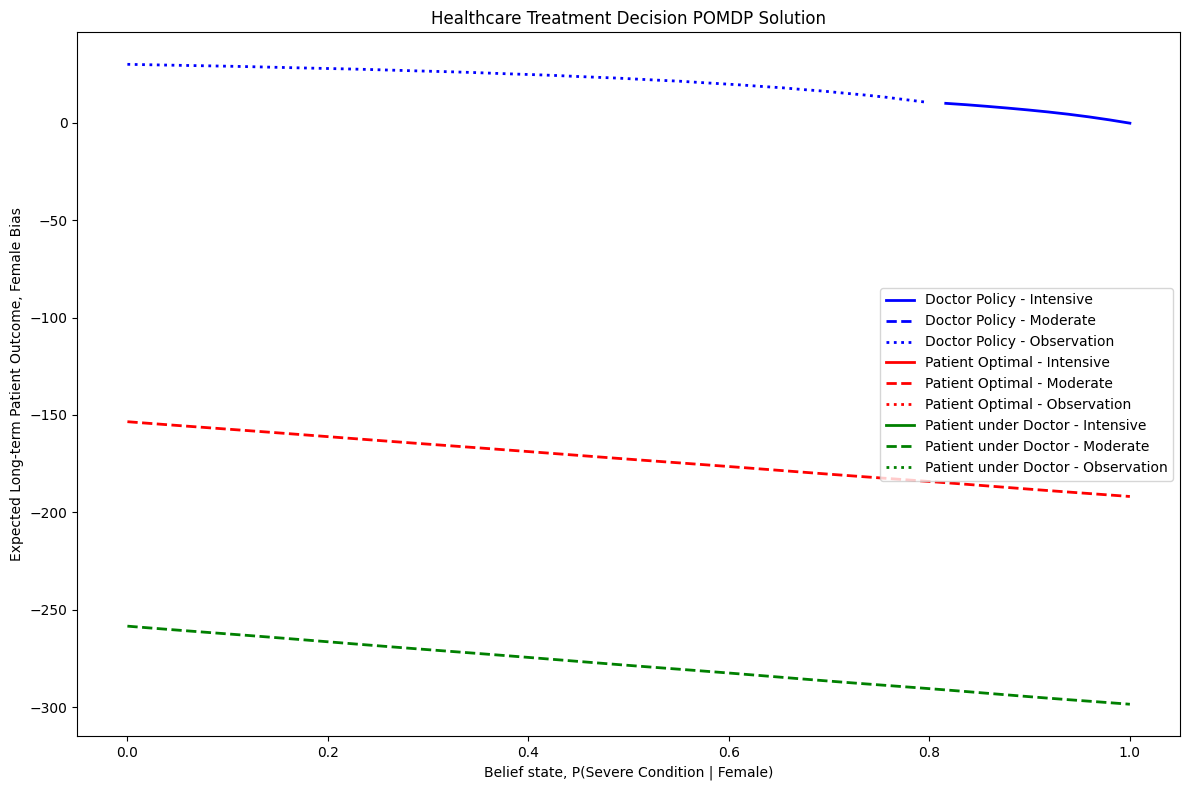

In [143]:
# calculate optimal values and actions for each policy

# run the solvers --> bias towards female patients, assuming overestimation
q_doctor = Q_bias(20, 'female', 'doctor') # optimal policy for doctor
q_patient_under_doctor_policy = Q_bias(20, 'female', 'patient') # patient's reward under doctor's policy
q_patient = Q_bias(20, 'female', 'singular') # optimal policy for patient


# doctor's policy
v_doctor = np.max(q_doctor, axis=1, keepdims=True)
p_doctor = (q_doctor == v_doctor) * 1.0
v_doctor = v_doctor.squeeze(-1)

# patient's policy
v_patient = np.max(q_patient, axis=1, keepdims=True)
p_patient = (q_patient == v_patient) * 1.0
v_patient = v_patient.squeeze(-1)

# patient under doctor's policy
v_patient_under_doctor = np.max(q_patient_under_doctor_policy, axis=1, keepdims=True)
p_patient_under_doctor = (q_patient_under_doctor_policy == v_patient_under_doctor) * 1.0
v_patient_under_doctor = v_patient_under_doctor.squeeze(-1)

# create the figure
from matplotlib import pyplot as plt
plt.figure(figsize=(12, 8))

# plot doctor's optimal policy (using solid lines)
plt.plot(B[p_doctor[:, 0] == 1], v_doctor[p_doctor[:, 0] == 1], 'b-', linewidth=2, label='Doctor Policy - Intensive')
plt.plot(B[p_doctor[:, 1] == 1], v_doctor[p_doctor[:, 1] == 1], 'b--', linewidth=2, label='Doctor Policy - Moderate')
plt.plot(B[p_doctor[:, 2] == 1], v_doctor[p_doctor[:, 2] == 1], 'b:', linewidth=2, label='Doctor Policy - Observation')

# Plot Patient's Optimal Policy (using red lines)
plt.plot(B[p_patient[:, 0] == 1], v_patient[p_patient[:, 0] == 1], 'r-', linewidth=2, label='Patient Optimal - Intensive')
plt.plot(B[p_patient[:, 1] == 1], v_patient[p_patient[:, 1] == 1], 'r--', linewidth=2, label='Patient Optimal - Moderate')
plt.plot(B[p_patient[:, 2] == 1], v_patient[p_patient[:, 2] == 1], 'r:', linewidth=2, label='Patient Optimal - Observation')

# plot patient under doctor's policy (using green lines)
plt.plot(B[p_patient_under_doctor[:, 0] == 1], v_patient_under_doctor[p_patient_under_doctor[:, 0] == 1], 'g-', linewidth=2, label='Patient under Doctor - Intensive')
plt.plot(B[p_patient_under_doctor[:, 1] == 1], v_patient_under_doctor[p_patient_under_doctor[:, 1] == 1], 'g--', linewidth=2, label='Patient under Doctor - Moderate')
plt.plot(B[p_patient_under_doctor[:, 2] == 1], v_patient_under_doctor[p_patient_under_doctor[:, 2] == 1], 'g:', linewidth=2, label='Patient under Doctor - Observation')

plt.legend()
plt.xlabel('Belief state, P(Severe Condition | Female)')
plt.ylabel('Expected Long-term Patient Outcome, Female Bias')
plt.title('Healthcare Treatment Decision POMDP Solution')
plt.tight_layout()


In [144]:
# Find the indices where the doctor's strategy changes
optimal_actions = np.argmax(q_doctor, axis=1)  # Get the index of the optimal action for each belief state
strategy_changes = []

for i in range(1, len(optimal_actions)):
    if optimal_actions[i] != optimal_actions[i-1]:
        strategy_changes.append(i)

# Print information about strategy changes and corresponding patient rewards
print("Doctor's Strategy Change Points:")
print("-" * 50)
print(f"{'Belief State':<15} {'From Action':<15} {'To Action':<15} {'Patient Reward':<15}")
print("-" * 50)

action_names = ['Intensive', 'Moderate', 'Observation']

for idx in strategy_changes:
    belief_value = B[idx]
    from_action = action_names[optimal_actions[idx-1]]
    to_action = action_names[optimal_actions[idx]]
    patient_reward = v_patient_under_doctor[idx]
    
    print(f"{belief_value:<15.3f} {from_action:<15} {to_action:<15} {patient_reward:<15.3f}")

# Additionally, you can compute the patient reward difference at these transition points
print("\nPatient Reward Analysis at Strategy Change Points:")
print("-" * 50)
print(f"{'Belief State':<15} {'Patient Optimal':<15} {'Under Doctor':<15} {'Difference':<15}")
print("-" * 50)

for idx in strategy_changes:
    belief_value = B[idx]
    patient_optimal = v_patient[idx]
    under_doctor = v_patient_under_doctor[idx]
    difference = patient_optimal - under_doctor
    
    print(f"{belief_value:<15.3f} {patient_optimal:<15.3f} {under_doctor:<15.3f} {difference:<15.3f}")

# You can also compute the average patient reward for each doctor strategy
print("\nAverage Patient Reward by Doctor's Strategy:")
print("-" * 50)
print(f"{'Doctor Strategy':<20} {'Avg Patient Reward':<20} {'Avg Difference from Optimal':<30}")
print("-" * 50)

for action_idx, action_name in enumerate(action_names):
    # Find belief states where doctor uses this strategy
    mask = optimal_actions == action_idx
    if np.any(mask):
        avg_reward = np.mean(v_patient_under_doctor[mask])
        avg_diff = np.mean(v_patient[mask] - v_patient_under_doctor[mask])
        print(f"{action_name:<20} {avg_reward:<20.3f} {avg_diff:<30.3f}")

Doctor's Strategy Change Points:
--------------------------------------------------
Belief State    From Action     To Action       Patient Reward 
--------------------------------------------------
0.816           Observation     Intensive       -291.079       

Patient Reward Analysis at Strategy Change Points:
--------------------------------------------------
Belief State    Patient Optimal Under Doctor    Difference     
--------------------------------------------------
0.816           -184.765        -291.079        106.313        

Average Patient Reward by Doctor's Strategy:
--------------------------------------------------
Doctor Strategy      Avg Patient Reward   Avg Difference from Optimal   
--------------------------------------------------
Intensive            -294.817             106.474                       
Observation          -274.342             105.612                       


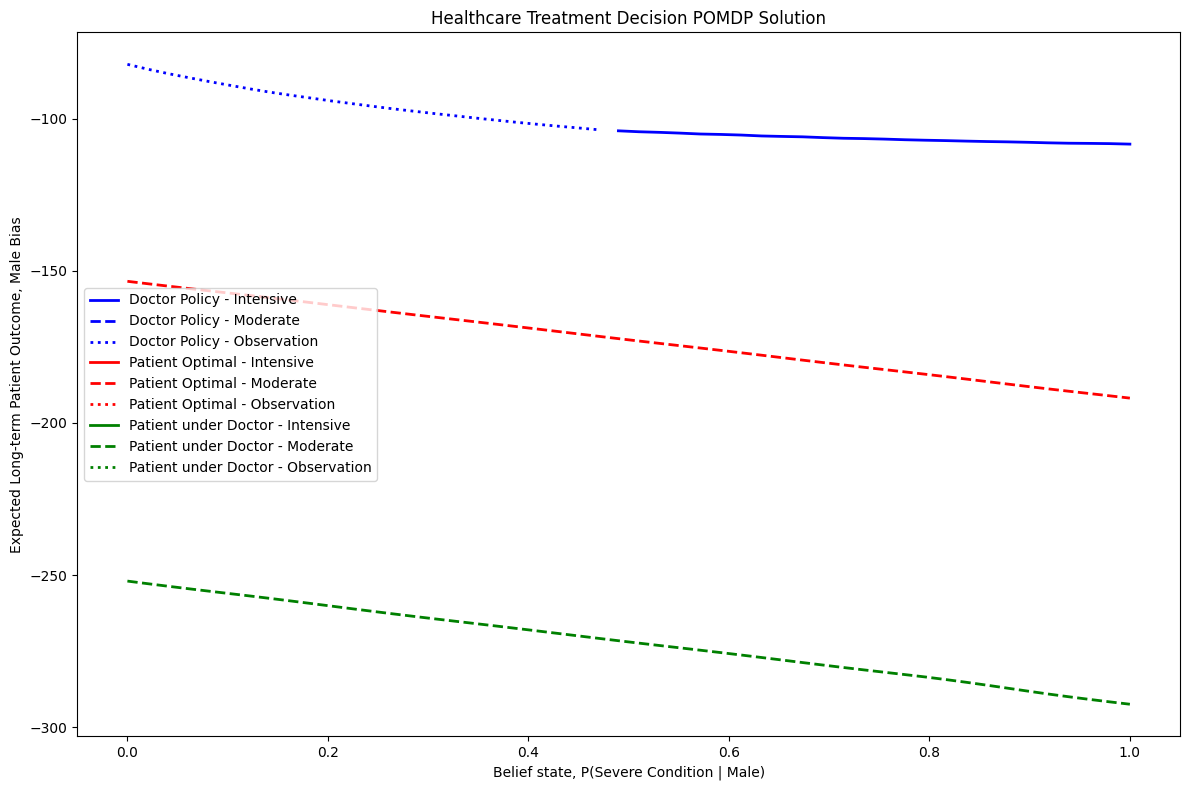

In [141]:
# calculate optimal values and actions for each policy

# run the solvers --> bias towards female patients, assuming overestimation
q_doctor = Q_bias(20, 'male', 'doctor') # optimal policy for doctor
q_patient_under_doctor_policy = Q_bias(20, 'male', 'patient') # patient's reward under doctor's policy
q_patient = Q_bias(20, 'male', 'singular') # optimal policy for patient


# doctor's policy
v_doctor = np.max(q_doctor, axis=1, keepdims=True)
p_doctor = (q_doctor == v_doctor) * 1.0
v_doctor = v_doctor.squeeze(-1)

# patient's policy
v_patient = np.max(q_patient, axis=1, keepdims=True)
p_patient = (q_patient == v_patient) * 1.0
v_patient = v_patient.squeeze(-1)

# patient under doctor's policy
v_patient_under_doctor = np.max(q_patient_under_doctor_policy, axis=1, keepdims=True)
p_patient_under_doctor = (q_patient_under_doctor_policy == v_patient_under_doctor) * 1.0
v_patient_under_doctor = v_patient_under_doctor.squeeze(-1)

# create the figure
from matplotlib import pyplot as plt
plt.figure(figsize=(12, 8))

# plot doctor's optimal policy (using solid lines)
plt.plot(B[p_doctor[:, 0] == 1], v_doctor[p_doctor[:, 0] == 1], 'b-', linewidth=2, label='Doctor Policy - Intensive')
plt.plot(B[p_doctor[:, 1] == 1], v_doctor[p_doctor[:, 1] == 1], 'b--', linewidth=2, label='Doctor Policy - Moderate')
plt.plot(B[p_doctor[:, 2] == 1], v_doctor[p_doctor[:, 2] == 1], 'b:', linewidth=2, label='Doctor Policy - Observation')

# Plot Patient's Optimal Policy (using red lines)
plt.plot(B[p_patient[:, 0] == 1], v_patient[p_patient[:, 0] == 1], 'r-', linewidth=2, label='Patient Optimal - Intensive')
plt.plot(B[p_patient[:, 1] == 1], v_patient[p_patient[:, 1] == 1], 'r--', linewidth=2, label='Patient Optimal - Moderate')
plt.plot(B[p_patient[:, 2] == 1], v_patient[p_patient[:, 2] == 1], 'r:', linewidth=2, label='Patient Optimal - Observation')

# plot patient under doctor's policy (using green lines)
plt.plot(B[p_patient_under_doctor[:, 0] == 1], v_patient_under_doctor[p_patient_under_doctor[:, 0] == 1], 'g-', linewidth=2, label='Patient under Doctor - Intensive')
plt.plot(B[p_patient_under_doctor[:, 1] == 1], v_patient_under_doctor[p_patient_under_doctor[:, 1] == 1], 'g--', linewidth=2, label='Patient under Doctor - Moderate')
plt.plot(B[p_patient_under_doctor[:, 2] == 1], v_patient_under_doctor[p_patient_under_doctor[:, 2] == 1], 'g:', linewidth=2, label='Patient under Doctor - Observation')

plt.legend()
plt.xlabel('Belief state, P(Severe Condition | Male)')
plt.ylabel('Expected Long-term Patient Outcome, Male Bias')
plt.title('Healthcare Treatment Decision POMDP Solution')
plt.tight_layout()


In [142]:
# Find the indices where the doctor's strategy changes
optimal_actions = np.argmax(q_doctor, axis=1)  # Get the index of the optimal action for each belief state
strategy_changes = []

for i in range(1, len(optimal_actions)):
    if optimal_actions[i] != optimal_actions[i-1]:
        strategy_changes.append(i)

# Print information about strategy changes and corresponding patient rewards
print("Doctor's Strategy Change Points:")
print("-" * 50)
print(f"{'Belief State':<15} {'From Action':<15} {'To Action':<15} {'Patient Reward':<15}")
print("-" * 50)

action_names = ['Intensive', 'Moderate', 'Observation']

for idx in strategy_changes:
    belief_value = B[idx]
    from_action = action_names[optimal_actions[idx-1]]
    to_action = action_names[optimal_actions[idx]]
    patient_reward = v_patient_under_doctor[idx]
    
    print(f"{belief_value:<15.3f} {from_action:<15} {to_action:<15} {patient_reward:<15.3f}")

# Additionally, you can compute the patient reward difference at these transition points
print("\nPatient Reward Analysis at Strategy Change Points:")
print("-" * 50)
print(f"{'Belief State':<15} {'Patient Optimal':<15} {'Under Doctor':<15} {'Difference':<15}")
print("-" * 50)

for idx in strategy_changes:
    belief_value = B[idx]
    patient_optimal = v_patient[idx]
    under_doctor = v_patient_under_doctor[idx]
    difference = patient_optimal - under_doctor
    
    print(f"{belief_value:<15.3f} {patient_optimal:<15.3f} {under_doctor:<15.3f} {difference:<15.3f}")

# You can also compute the average patient reward for each doctor strategy
print("\nAverage Patient Reward by Doctor's Strategy:")
print("-" * 50)
print(f"{'Doctor Strategy':<20} {'Avg Patient Reward':<20} {'Avg Difference from Optimal':<30}")
print("-" * 50)

for action_idx, action_name in enumerate(action_names):
    # Find belief states where doctor uses this strategy
    mask = optimal_actions == action_idx
    if np.any(mask):
        avg_reward = np.mean(v_patient_under_doctor[mask])
        avg_diff = np.mean(v_patient[mask] - v_patient_under_doctor[mask])
        print(f"{action_name:<20} {avg_reward:<20.3f} {avg_diff:<30.3f}")

Doctor's Strategy Change Points:
--------------------------------------------------
Belief State    From Action     To Action       Patient Reward 
--------------------------------------------------
0.490           Observation     Intensive       -271.522       

Patient Reward Analysis at Strategy Change Points:
--------------------------------------------------
Belief State    Patient Optimal Under Doctor    Difference     
--------------------------------------------------
0.490           -172.289        -271.522        99.233         

Average Patient Reward by Doctor's Strategy:
--------------------------------------------------
Doctor Strategy      Avg Patient Reward   Avg Difference from Optimal   
--------------------------------------------------
Intensive            -281.692             99.627                        
Observation          -261.381             98.924                        


## Documentation of Incompatibilities

We are unable to pass multi-value input to memo funcitons -- strings specificially are not supported. 

In [110]:
import jax.numpy as jnp

In [112]:
@memo(cache=True)
def Q[b: B, a: A](t, gender):
    doctor: knows(b, a)  # the doctor knows the current belief state and action.
    doctor: thinks[
        env: knows(b, a),  # the environment also knows the current belief state and action.
        env: given(s in S, wpp=(
            
            get_belief_f(b, s) if {gender == 'female'} else get_belief_m(b, s)
                                )),  # the environment samples the true state `s` based on the belief `b`.
        env: given(s_ in S, wpp=Tr(s, a, s_)),  # the environment transitions to the next state `s_` based on the current state `s` and action `a`.
        env: given(o in O, wpp=Obs(o, s_, a))  # the environment generates an observation `o` based on the next state `s_` and action `a`.
    ]
    doctor: snapshots_self_as(future_doctor)  # the doctor imagines a future version of themselves.
    return doctor[
        E[R_doctor(env.s, a)] +  # the expected immediate reward for the doctor.
        (0.0 if t <= 0 else 0.9 * imagine[  # if time `t` is greater than 0, the doctor imagines future rewards.
            future_doctor: observes [env.o] is env.o,  # the future doctor observes the observation `o`.
            future_doctor: chooses(b_ in B, wpp=exp(-130.0 * abs(E[env.s_ == 0] - b_))),  # the future doctor updates their belief state `b_` to minimize the distance to the true state.
            future_doctor: chooses(a_ in A, to_maximize=Q[b_, a_](t - 1, gender)),  # the future doctor chooses the action `a_` that maximizes the Q-value for the updated belief state `b_` and time `t-1`.
            E[future_doctor[ Q[b_, a_](t - 1, gender) ]]  # the expected Q-value for the future doctor.
        ])
    ]
# measure the time it takes to compute the Q-value for a belief state `b` and action `a` at time `t=100`.
%timeit -r 10 -n 10 Q.cache_clear(); Q(100, 'female').block_until_ready()

TypeError: Error interpreting argument to <function _make_Q.<locals>._jit_Q at 0x000002F470772DE0> as an abstract array. The problematic value is of type <class 'str'> and was passed to the function at path gender.
This typically means that a jit-wrapped function was called with a non-array argument, and this argument was not marked as static using the static_argnums or static_argnames parameters of jax.jit.

In [113]:
@memo(cache=True)
def Q[b: B, a: A](t, is_female):
    doctor: knows(b, a)  # the doctor knows the current belief state and action.
    doctor: thinks[
        env: knows(b, a),  # the environment also knows the current belief state and action.
        env: given(s in S, wpp=jnp.where(
            is_female,
            get_belief_f(b, s),
            get_belief_m(b, s)
        )),  # the environment samples the true state `s` based on the belief `b`.
        env: given(s_ in S, wpp=Tr(s, a, s_)),  # the environment transitions to the next state `s_` based on the current state `s` and action `a`.
        env: given(o in O, wpp=Obs(o, s_, a))  # the environment generates an observation `o` based on the next state `s_` and action `a`.
    ]
    doctor: snapshots_self_as(future_doctor)  # the doctor imagines a future version of themselves.
    return doctor[
        E[R_doctor(env.s, a)] +  # the expected immediate reward for the doctor.
        (0.0 if t <= 0 else 0.9 * imagine[  # if time `t` is greater than 0, the doctor imagines future rewards.
            future_doctor: observes [env.o] is env.o,  # the future doctor observes the observation `o`.
            future_doctor: chooses(b_ in B, wpp=exp(-130.0 * abs(E[env.s_ == 0] - b_))),  # the future doctor updates their belief state `b_` to minimize the distance to the true state.
            future_doctor: chooses(a_ in A, to_maximize=Q[b_, a_](t - 1, is_female)),  # the future doctor chooses the action `a_` that maximizes the Q-value for the updated belief state `b_` and time `t-1`.
            E[future_doctor[ Q[b_, a_](t - 1, is_female) ]]  # the expected Q-value for the future doctor.
        ])
    ]

memo.core.MemoError: Unknown expression syntax
  file: "3031707369.py", line 6, in @memo Q
            env: given(s in S, wpp=jnp.where(
                                   ^

  hint: The full expression is
        Call(func=Attribute(value=Name(id='jnp', ctx=Load()),
        attr='where', ctx=Load()), args=[Name(id='is_female',
        ctx=Load()), Call(func=Name(id='get_belief_f', ctx=Load()),
        args=[Name(id='b', ctx=Load()), Name(id='s', ctx=Load())]),
        Call(func=Name(id='get_belief_m', ctx=Load()),
        args=[Name(id='b', ctx=Load()), Name(id='s', ctx=Load())])])

  info: You are using memo 0.5.1, JAX 0.5.0, Python 3.13.1 on Windows.


In [99]:
q = Q_g(10)

TracerBoolConversionError: Attempted boolean conversion of traced array with shape bool[].
The error occurred while tracing the function get_belief_g at C:\Users\idilk\AppData\Local\Temp\ipykernel_7588\2036635374.py:8 for jit. This concrete value was not available in Python because it depends on the value of the argument gender.
See https://jax.readthedocs.io/en/latest/errors.html#jax.errors.TracerBoolConversionError

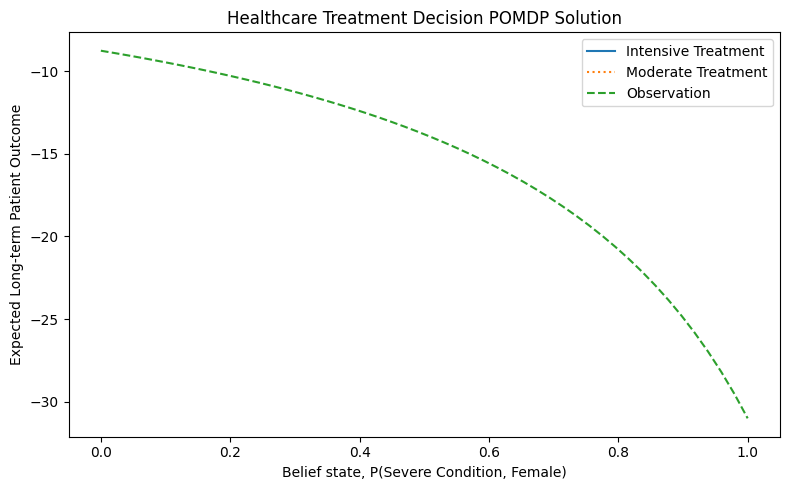

In [60]:

# # run the solver
q = Q(10)
v = np.max(q, axis=1, keepdims=True)
p = (q == v) * 1.0
v = v.squeeze(-1)

# make the figure
from matplotlib import pyplot as plt
plt.figure(figsize=(8, 5))
plt.plot(B[p[:, 0] > 0], v[p[:, 0] > 0], label='Intensive Treatment')
plt.plot(B[p[:, 1] > 0], v[p[:, 1] > 0], ':', label='Moderate Treatment')
plt.plot(B[p[:, 2] > 0], v[p[:, 2] > 0], '--', label='Observation')
plt.legend()
plt.xlabel('Belief state, P(Severe Condition, Female)')
plt.ylabel('Expected Long-term Patient Outcome')
plt.title('Healthcare Treatment Decision POMDP Solution')
plt.tight_layout()
plt.savefig('healthcare_pomdp_f_base.pdf')

290 ms ± 27.5 ms per loop (mean ± std. dev. of 10 runs, 10 loops each)


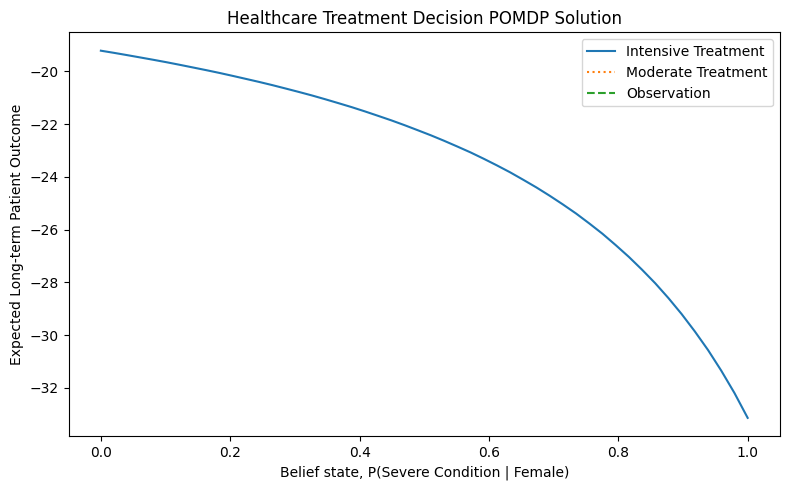

In [68]:
@memo(cache=True)
def Q[b: B, a: A](t):
    alice: knows(b, a)
    alice: thinks[
        env: knows(b, a),
        env: chooses(s in S, wpp=get_belief_f(b, s)),
        env: chooses(s_ in S, wpp=Tr(s, a, s_)),
        env: chooses(o in O, wpp=Obs(o, s_, a))
    ]
    
    # return the probability distribution--now with minimizing the total loss
    return alice[
        E[R_doctor(env.s, a)] + (0.0 if t <= 0 else 0.9 * imagine[
            future_alice: observes [env.o] is env.o,
            future_alice: chooses(b_ in B, wpp=exp(-100.0 * abs(E[env.s_ == 0] - b_))),
            future_alice: chooses(a_ in A, to_maximize=Q[b_, a_](t - 1)),
            E[future_alice[ Q[b_, a_](t - 1) ] ]
        ])
    ]

%timeit -r 10 -n 10 Q.cache_clear(); Q(100).block_until_ready()


# # run the solver
q = Q(10)
v = np.max(q, axis=1, keepdims=True)
p = (q == v) * 1.0
v = v.squeeze(-1)

# make the figure
from matplotlib import pyplot as plt
plt.figure(figsize=(8, 5))
plt.plot(B[p[:, 0] > 0], v[p[:, 0] > 0], label='Intensive Treatment')
plt.plot(B[p[:, 1] > 0], v[p[:, 1] > 0], ':', label='Moderate Treatment')
plt.plot(B[p[:, 2] > 0], v[p[:, 2] > 0], '--', label='Observation')
plt.legend()
plt.xlabel('Belief state, P(Severe Condition | Female)')
plt.ylabel('Expected Long-term Patient Outcome')
plt.title('Healthcare Treatment Decision POMDP Solution')
plt.tight_layout()
plt.savefig('healthcare_pomdp_f.pdf')

284 ms ± 13.5 ms per loop (mean ± std. dev. of 10 runs, 10 loops each)


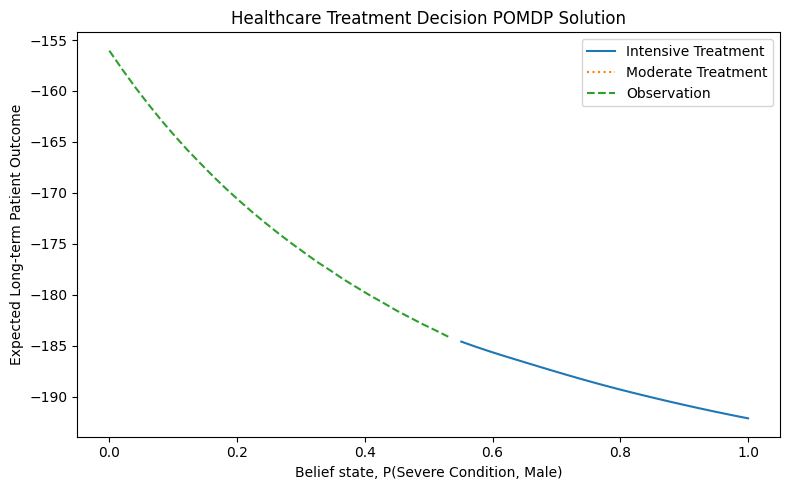

In [66]:
# now running this with men:

@jax.jit
def get_belief_m(b, s):
    probs = jnp.zeros(3)
    
    # assign probabilities based on belief b
    # for male patients (with underestimation bias applied)
    probs = probs.at[S.Severe].set(b)
    probs = probs.at[S.Moderate].set((1 - b) * 0.6)
    probs = probs.at[S.Mild].set((1 - b) * 0.4)
    
    # apply gender bias factors
    bias_factors = jnp.array([5, 3, 1])  # For Severe, Moderate, Mild
    biased_probs = probs * bias_factors
    
    # normalize to ensure probabilities sum to 1
    normalized_probs = biased_probs / jnp.sum(biased_probs)
    
    # return probability for the specific state s
    return normalized_probs[s]

@memo(cache=True)
def Q[b: B, a: A](t):
    alice: knows(b, a)
    alice: thinks[
        env: knows(b, a),
        env: chooses(s in S, wpp=get_belief_m(b, s)),
        env: chooses(s_ in S, wpp=Tr(s, a, s_)),
        env: chooses(o in O, wpp=Obs(o, s_, a))
    ]
    
    # return the probability distribution--now with minimizing the total loss
    return alice[
        E[R(env.s, a)] + (0.0 if t <= 0 else 0.9 * imagine[
            future_alice: observes [env.o] is env.o,
            future_alice: chooses(b_ in B, wpp=exp(-100.0 * abs(E[env.s_ == 0] - b_))),
            future_alice: chooses(a_ in A, to_maximize=Q[b_, a_](t - 1)),
            E[future_alice[ Q[b_, a_](t - 1) ] ]
        ])
    ]

%timeit -r 10 -n 10 Q.cache_clear(); Q(100).block_until_ready()


# # run the solver
q = Q(10)
v = np.max(q, axis=1, keepdims=True)
p = (q == v) * 1.0
v = v.squeeze(-1)

# make the figure
from matplotlib import pyplot as plt
plt.figure(figsize=(8, 5))
plt.plot(B[p[:, 0] > 0], v[p[:, 0] > 0], label='Intensive Treatment')
plt.plot(B[p[:, 1] > 0], v[p[:, 1] > 0], ':', label='Moderate Treatment')
plt.plot(B[p[:, 2] > 0], v[p[:, 2] > 0], '--', label='Observation')
plt.legend()
plt.xlabel('Belief state, P(Severe Condition | Male)')
plt.ylabel('Expected Long-term Patient Outcome')
plt.title('Healthcare Treatment Decision POMDP Solution')
plt.tight_layout()
plt.savefig('healthcare_pomdp_m.pdf')


In [64]:


# @memo(cache=True)
# def Q[b: B, a: A, gender: G](t):
#     alice: knows(b, a, gender)
#     alice: thinks[
#         env: knows(b, a, gender),
#         env: chooses(s in S, wpp=get_belief_f(b, s)),
#         env: chooses(s_ in S, wpp=Tr(s, a, s_)),
#         env: chooses(o in O, wpp=Obs(o, s_, a, gender))
#     ]
#     alice: snapshots_self_as(future_alice)
    
#     return alice[
#         E[R(env.s, a)] + (0.0 if t <= 0 else 0.9 * imagine[
#             future_alice: observes [env.o] is env.o,         
#             # use the deterministic belief update function
#             # exp stands for softmax
            
#             future_alice: chooses(b_ in B, wpp=exp(-100.0 * abs(E[env.s_ == {S.Severe}] - b_))),
#             # if gender == 1:
#             #     future_alice: chooses(b_ in B, wpp=exp(-100.0 * abs(update_belief(b, a, env.o, env.gender) - b_))),
#             # else:
#             #     future_alice: chooses(b_ in B, wpp=exp(-100.0 * abs(update_belief(b, a, env.o, env.gender) - b_))),
#             future_alice: chooses(a_ in A, to_maximize=Q[b_, a_, env.gender](t - 1)),
#             E[ future_alice[ Q[b_, a_, env.gender](t - 1) ] ]
#         ])
#     ]
    



# unbiased example for reference
# @memo(cache=True)
# def Q[b: B, a: A](t):
#     alice: knows(b, a) # belief and action
#     alice: thinks[
#         env: knows(b, a),
#         env: chooses(s in S, wpp=get_belief(b, s)),
#         env: chooses(s_ in S, wpp=Tr(s, a, s_)),
#         env: chooses(o in O, wpp=Obs(o, s_, a))
#     ]
#     alice: snapshots_self_as(future_alice)
    
#     return alice[
#         E[R(env.s, a)] + (0.0 if t <= 0 else 0.9 * imagine[
#             future_alice: observes [env.o] is env.o,
#             future_alice: chooses(b_ in B, wpp=exp(-100.0 * abs(E[env.s_ == 0] - b_))),
#             future_alice: chooses(a_ in A, to_maximize=Q[b_, a_](t - 1)),
#             E[future_alice[ Q[b_, a_](t - 1) ] ]
#         ])
#     ]

In [67]:
import jax
import jax.numpy as jnp
import numpy as np
from functools import partial
from memo import memo

# Define state, action, and observation spaces
S = [0, 1, 2]  # States: 0, 1, 2
A = [0, 1]     # Actions: 0, 1
O = [0, 1]     # Observations: 0, 1

# Generate belief space (discretized simplex)
def generate_belief_space(n_points=20):
    beliefs = []
    for i in range(n_points):
        for j in range(n_points - i):
            # Barycentric coordinates
            p0 = i / (n_points - 1)
            p1 = j / (n_points - 1)
            p2 = 1 - p0 - p1
            if p2 >= 0:  # Ensure valid probability
                beliefs.append(jnp.array([p0, p1, p2]))
    return beliefs

B = generate_belief_space()

# JAX-optimized functions for POMDP dynamics
@jax.jit
def get_belief(b, s):
    """Get probability of state s according to belief b"""
    return jnp.take(b, s)

@jax.jit
def Tr(s, a, s_prime):
    """Transition function P(s'|s,a)"""
    # Example transition dynamics
    if a == 0:  # Action 0
        if s == 0:
            return jnp.array([0.7, 0.2, 0.1])[s_prime]
        elif s == 1:
            return jnp.array([0.1, 0.8, 0.1])[s_prime]
        else:  # s == 2
            return jnp.array([0.1, 0.1, 0.8])[s_prime]
    else:  # Action 1
        if s == 0:
            return jnp.array([0.8, 0.1, 0.1])[s_prime]
        elif s == 1:
            return jnp.array([0.1, 0.7, 0.2])[s_prime]
        else:  # s == 2
            return jnp.array([0.2, 0.2, 0.6])[s_prime]

@jax.jit
def Obs(o, s, a):
    """Observation function P(o|s,a)"""
    # Example observation dynamics
    if a == 0:  # Action 0
        if s == 0:
            return jnp.array([0.8, 0.2])[o]
        elif s == 1:
            return jnp.array([0.5, 0.5])[o]
        else:  # s == 2
            return jnp.array([0.2, 0.8])[o]
    else:  # Action 1
        if s == 0:
            return jnp.array([0.9, 0.1])[o]
        elif s == 1:
            return jnp.array([0.4, 0.6])[o]
        else:  # s == 2
            return jnp.array([0.1, 0.9])[o]

@jax.jit
def R_doctor(s, a):
    """Reward function R(s,a)"""
    # Example reward function
    if s == 0:  # Healthy state
        return 5.0 if a == 0 else 0.0
    elif s == 1:  # Mild symptoms
        return 3.0 if a == 0 else 8.0
    else:  # s == 2, Severe symptoms
        return -2.0 if a == 0 else 10.0

# JAX function to compute posterior belief
@partial(jax.jit, static_argnums=(1, 2))
def compute_posterior(b, a, o):
    """Compute posterior belief P(s'|b,a,o)"""
    # Initialize array for unnormalized posterior
    unnormalized = jnp.zeros(3)
    
    # For each possible next state s'
    for s_prime in range(3):
        # P(o|s',a)
        obs_prob = Obs(o, s_prime, a)
        
        # Sum over current states: ∑_s P(s'|s,a) * b(s)
        trans_sum = 0.0
        for s in range(3):
            trans_sum += Tr(s, a, s_prime) * b[s]
        
        # P(s'|b,a,o) ∝ P(o|s',a) * ∑_s P(s'|s,a) * b(s)
        unnormalized = unnormalized.at[s_prime].set(obs_prob * trans_sum)
    
    # Normalize
    return unnormalized / jnp.sum(unnormalized)

# JAX function to compute belief distance
@jax.jit
def belief_distance(b1, b2):
    """Compute L1 distance between beliefs"""
    return jnp.sum(jnp.abs(b1 - b2))

# Helper function for memo to use JAX belief matching
def belief_match(b_, posterior_dict):
    """Return high value when belief matches posterior"""
    b_array = jnp.array([b_[s] for s in range(3)])
    posterior_array = jnp.array([posterior_dict[s] for s in range(3)])
    diff_sum = jnp.sum(jnp.abs(posterior_array - b_array))
    return float(jnp.exp(-100.0 * diff_sum))

# Convert JAX array to dictionary for memo
def array_to_dict(arr):
    """Convert JAX array to dictionary for memo"""
    return {s: float(arr[s]) for s in range(len(arr))}

# Convert dictionary to JAX array
def dict_to_array(d):
    """Convert dictionary to JAX array"""
    return jnp.array([d[s] for s in range(len(d))])

# POMDP solver using memo
@memo(cache=True)
def Q[b: B, a: A](t):
    doctor: knows(b, a)
    
    doctor: thinks[
        env: knows(b, a),
        env: chooses(s in S, wpp=get_belief(b, s)),
        env: chooses(s_ in S, wpp=Tr(s, a, s_)),
        env: chooses(o in O, wpp=Obs(o, s_, a))
    ]
    doctor: snapshots_self_as(future_doctor)
    
    # Get the observation that future_doctor will receive
    
    # Convert belief to JAX array if it's not already
    belief_array = b

    # Compute posterior using JAX
    posterior_array = compute_posterior(belief_array, a, obs)
    
    # Convert to dictionary for memo
    posterior_dict = array_to_dict(posterior_array)
    
    return doctor[
        E[R_doctor(env.s, a)] + (0.0 if t <= 0 else 0.9 * imagine[
            future_doctor: observes [env.o] is env.o,
            future_doctor: chooses(b_ in B, wpp=exp(-100.0 * belief_distance(dict_to_array(b_), posterior_array))),
            future_doctor: chooses(a_ in A, to_maximize=Q[b_, a_](t - 1)),
            E[future_doctor[ Q[b_, a_](t - 1) ] ]
        ])
    ]

# Function to find optimal policy
def optimal_policy(horizon=10):
    """Compute optimal policy for all belief states"""
    policy = {}
    values = {}
    
    for b in B:
        b_dict = array_to_dict(b)
        best_a = None
        best_v = float('-inf')
        
        for a in A:
            v = Q[b_dict, a](horizon).block_until_ready()
            if v > best_v:
                best_v = v
                best_a = a
        
        policy[tuple(b)] = best_a
        values[tuple(b)] = best_v
    
    return policy, values

# Example usage
if __name__ == "__main__":
    # Clear cache and compute optimal policy
    Q.cache_clear()
    policy, values = optimal_policy(horizon=5)
    
    # Print some example policy decisions
    print("Example policy decisions:")
    for i, b in enumerate(B[:5]):
        print(f"Belief: {b}, Action: {policy[tuple(b)]}, Value: {values[tuple(b)]:.2f}")
    
    # Benchmark performance
    import time
    start = time.time()
    Q.cache_clear()
    Q[array_to_dict(B[0]), 0](10).block_until_ready()
    end = time.time()
    print(f"Time to compute Q-value: {end - start:.4f} seconds")

memo.core.MemoError: Unknown statement syntax
  file: "537615772.py", line 145, in @memo Q
        belief_array = b
        ^

  hint: The full statement is Assign(targets=[Name(id='belief_array',
        ctx=Store())], value=Name(id='b', ctx=Load()))

  info: You are using memo 0.5.1, JAX 0.5.0, Python 3.13.1 on Windows.


## Inference model 

## Tests with memo

In [ ]:
# create a modified Q-function that uses doctor's actions but patient's rewards that calls the doctor's Q-function
# running the function within memo however results in a recursion error
@memo(cache=True)
def Q_patient_under_doctor_policy[b: B, a:A](t):
    doctor: knows(b)
    patient: knows(b)
    
    # get the doctor's optimal action for this belief state    
    doctor: thinks[
        env: knows(b),
        env: given(s in S, wpp=get_belief(b, s)),
        env: given(s_ in S, wpp=Tr(s, a, s_)),
        env: given(o in O, wpp=Obs(o, s_, a)),
        env: chooses(a in A, to_maximize=Q[b, a](t))
    ]
    doctor: snapshots_self_as(future_doctor)

    return doctor[
        E[R_patient(env.s, a)] +  # Patient's reward function
        (0.0 if t <= 0 else 0.9 * imagine[
            future_doctor: observes [env.o] is env.o,
            future_doctor: chooses(b_ in B, wpp=exp(-130.0 * abs(E[env.s_ == 0] - b_))),
            E[future_doctor[ Q_patient_under_doctor_policy[b_](t - 1) ]]
        ])
    ]

memo.core.MemoError: Unknown choice env.a
  file: "279490933.py", line 12, in @memo Q_patient_under_doctor_policy
            env: given(s_ in S, wpp=Tr(s, a, s_)),
                                          ^

  hint: Did you perhaps misspell a? env is not yet aware of any choice
        called a. Or, did you forget to call env.chooses(a ...) or
        env.knows(a) earlier in the memo?

  ctxt: This error was encountered in the frame of env, as modeled by
        doctor.  In that frame, env is currently modeling the
        following 3 choices: b, s, s_.

  info: You are using memo 0.5.1, JAX 0.5.0, Python 3.13.1 on Windows.


In [ ]:
# create a modified Q-function that uses doctor's actions but patient's rewards that calls the doctor's Q-function
# running the function within memo however results in a recursion error
@memo(cache=True)
def Q_patient_under_doctor_policy[b: B, a:A](t):
    doctor: knows(b)
    patient: knows(b)
    
    # get the doctor's optimal action for this belief state    
    doctor: thinks[
        env: knows(b),
        env: given(s in S, wpp=get_belief(b, s)),
        env: given(s_ in S, wpp=Tr(s, a, s_)),
        env: given(o in O, wpp=Obs(o, s_, a)),
        env: chooses(a in A, to_maximize=Q[b, a](t))
    ]
    doctor: snapshots_self_as(future_doctor)

    return doctor[
        E[R_patient(env.s, a)] +  # Patient's reward function
        (0.0 if t <= 0 else 0.9 * imagine[
            future_doctor: observes [env.o] is env.o,
            future_doctor: chooses(b_ in B, wpp=exp(-130.0 * abs(E[env.s_ == 0] - b_))),
            E[future_doctor[ Q_patient_under_doctor_policy[b_](t - 1) ]]
        ])
    ]

memo.core.MemoError: Unknown choice env.a
  file: "279490933.py", line 12, in @memo Q_patient_under_doctor_policy
            env: given(s_ in S, wpp=Tr(s, a, s_)),
                                          ^

  hint: Did you perhaps misspell a? env is not yet aware of any choice
        called a. Or, did you forget to call env.chooses(a ...) or
        env.knows(a) earlier in the memo?

  ctxt: This error was encountered in the frame of env, as modeled by
        doctor.  In that frame, env is currently modeling the
        following 3 choices: b, s, s_.

  info: You are using memo 0.5.1, JAX 0.5.0, Python 3.13.1 on Windows.


### Continious Transition

In [ ]:
# define a continuous state space from 0.0 (severe) to 2.0 (mild)
S_CONTINUOUS = jnp.linspace(0.0, 2.0, 21)
O_CONTINUOUS = jnp.linspace(0.0, 2.0, 21)
B = jnp.linspace(0.0, 2.0, 50) 

normpdfjit = jax.jit(normpdf)

# we keep the actions discrete 

# we need to be thresholding somewhere to identify the beliefs


@jax.jit
def Tr_cont(s, a, s_):
    # transition probabilities: P(s_|s,a)
    # how the patient's condition changes based on treatment
    transition_mu = s + a - 1.0
    transition_sigma = a # the more intense the treatment, the more likely the patient is to improve
    return normpdf(s_, transition_mu, transition_sigma)

@jax.jit
def Obs_cont(o, s, a):
    # observation probabilities: P(o|s,a)
    # what symptoms we observe given the true state and treatment
    observation_mu = s - 0.5
    observation_sigma = 0.1
    return normpdf(o, observation_mu, observation_sigma)
    

@jax.jit
def R_cont(s, a):
    # reward function balances health outcomes with treatment costs/risks
    
    # health state costs (being in worse states is worse)
    health_cost = -s**2 
    # other considerations tbd
    
    financial_incentive = np.array([0, 5, 7])[a]

    return health_cost + financial_incentive


# the states are now continous!!!

@memo(cache=True)
def Q_cont[b: B, a: A](t):
    doctor: knows(b, a)
    doctor: thinks[
        env: knows(b, a),
        env: given(s in S_CONTINUOUS, wpp=normpdfjit(b, s, 0.1)),
        env: given(s_ in S_CONTINUOUS, wpp=Tr_cont(s, a, s_)),
        env: given(o in O_CONTINUOUS, wpp=Obs_cont(o, s_, a))
    ]
    doctor: snapshots_self_as(future_doctor)
    return doctor[
        E[R_cont(env.s, a)] + (0.0 if t <= 0 else 0.9 * imagine[
        future_doctor: observes [env.o] is env.o,
        future_doctor: chooses(b_ in B, wpp=normpdfjit(b, 0.2, 0.1)), # this statement is changed to maximize mild symptoms
        future_doctor: chooses(a_ in A, to_maximize=Q_cont[b_, a_](t - 1)),
        E[future_doctor[ Q_cont[b_, a_](t - 1) ] ]
    ])
    ]



# @jax.jit
# def get_belief_cont(b, s):
#     # create a vector of probabilities 



# what we know: moderate cases have the most uncertainty
# mild cases have less
# severe cases have the least uncertainty
# we can define everything as a cont distribution and get the cdf
# this allows us to define the thresholds on what severe means
# we can then pass the reward function as a numeric value and then minimize it




%timeit -r 10 -n 10 Q.cache_clear(); Q(100).block_until_ready()


